# TP3 - Breno Lobato Vila Nova - 11/09/2026
Este TP avalia a competência de avaliar análises de dados produzidas com suporte de IA generativa, cobrindo formulação de prompts para geração de código de limpeza, avaliação crítica de código gerado por IA, formulação de perguntas analíticas com apoio de IA, execução de análise descritiva com código gerado por LLM, aplicação de testes de hipótese com SciPy via LLM (com foco em intervalos de confiança, não apenas p-valor), interpretação de p-valor e intervalo de confiança, e avaliação da qualidade de interpretações geradas por LLMs.

Este TP reutiliza a mesma base de tickets da CloudDesk dos TPs anteriores, sem gerar dados novos. Recarregue os três arquivos brutos (tickets_suporte.csv, planos_clientes.xlsx e chatbot_triagem.json) que você já tem salvos localmente e repita, no início do seu notebook, as mesmas etapas de conversão de tipos, tratamento de nulos, remoção de duplicatas e combinação (merge) feitas no TP1, chegando ao mesmo DataFrame consolidado usado a partir daqui.

## Recriando dataframes anteriores

Em vez de repetir manualmente os passos de criação e limpeza dos dados feitos no TP1 e no TP2, essa etapa baixa dois scripts Python publicados no repositório público desta disciplina no GitHub (via raw.githubusercontent.com), salva-os localmente e importa deles as funções que recriam o mesmo DataFrame consolidado usado a partir do TP2:

- `criar_dataframes.py`: recria os DataFrames brutos de tickets, planos e triagem do chatbot direto em memória (TP1 - Exercícios 1 e 2).
- `consolidar_dataframes.py`: aplica a conversão de tipos, o tratamento de nulos, a remoção de duplicatas e o merge das três fontes (TP1 - Exercícios 3, 6, 7 e 8), chegando ao DataFrame final.

In [11]:
import urllib.request
from pathlib import Path

GITHUB_RAW_BASE = "https://raw.githubusercontent.com/kick250/estatistica_aplicada/refs/heads/main/local/data_scripts"
SCRIPTS = ["criar_dataframes.py", "consolidar_dataframes.py"]

data_scripts_dir = Path("data_scripts")
data_scripts_dir.mkdir(exist_ok=True)

for nome_arquivo in SCRIPTS:
    destino = data_scripts_dir / nome_arquivo
    urllib.request.urlretrieve(f"{GITHUB_RAW_BASE}/{nome_arquivo}", destino)

In [12]:
import pandas as pd

from data_scripts.criar_dataframes import criar_dataframes_brutos
from data_scripts.consolidar_dataframes import consolidar

tickets_df, planos_df, chatbot_df = criar_dataframes_brutos()
df = consolidar(tickets_df, planos_df, chatbot_df)
df.shape

(4000, 13)

## Exercício 1

### Contexto

Na CloudDesk, a demanda por relatórios de dados cresceu, e seu líder técnico pediu que você acelerasse a etapa de limpeza de dados usando um LLM (ChatGPT, Gemini , Claude, Grok, outros) como copiloto, em vez de escrever manualmente cada linha de tratamento como nas etapas anteriores da disciplina, sobre a mesma base de tickets já usada no TP1 e no TP2. A tarefa não é delegar a decisão ao modelo, e sim usar o LLM para gerar candidatos de código que você mesmo vai revisar. Um prompt vago produz código genérico; um prompt específico, com o schema e as regras de negócio do dataset, produz código diretamente aplicável.

### Tarefa
1. Escreva um prompt para um LLM pedindo código pandas que trate valores ausentes em tempo_resposta_horas e remova duplicatas em ticket_id, incluindo no prompt o nome exato das colunas e o critério de negócio (ex.: preencher com a mediana por categoria).
2. Cole a resposta do LLM no notebook, junto com o prompt utilizado.
3. Execute o código gerado sobre a base de tickets e confirme se o resultado é equivalente ao obtido manualmente no TP1.


### Tarefa 1. Escreva um prompt para um LLM pedindo código pandas que trate valores ausentes em tempo_resposta_horas e remova duplicatas em ticket_id, incluindo no prompt o nome exato das colunas e o critério de negócio (ex.: preencher com a mediana por categoria).

> Preciso de código pandas para tratar dois problemas no DataFrame `df` de tickets de suporte da CloudDesk:
> 1. A coluna `tempo_resposta_horas` tem valores ausentes. Preencha-os com a MEDIANA de `tempo_resposta_horas` calculada POR CATEGORIA (coluna `categoria`) — ou seja, cada linha ausente deve receber a mediana do seu próprio grupo de categoria, não a mediana global.
> 2. A coluna `ticket_id` é a chave única de cada ticket, mas existem linhas duplicadas (reenvios do mesmo ticket). Remova as duplicatas por `ticket_id`, mantendo a primeira ocorrência.
> 3. Não altere nenhuma outra coluna nem remova linhas por outro motivo. Preserve o restante dos dados como está.
>
> Contexto de schema fornecido junto ao prompt: DataFrame consolidado `df` (resultado do merge de tickets + planos + triagem do chatbot), colunas: `ticket_id, cliente_id, data_abertura, canal, categoria, prioridade, tempo_resposta_horas, tempo_resolucao_horas, satisfacao_cliente, valor_plano, segmento, intencao_triagem, confianca_bot`.

### Tarefa 2. Cole a resposta do LLM no notebook, junto com o prompt utilizado.

**Resposta do LLM (explicação):**

Para o item 1, uso `groupby("categoria")["tempo_resposta_horas"].transform("median")` para obter, alinhado ao índice original, a mediana de cada grupo, e uso esse resultado com `fillna`. Isso evita vazar a mediana global e preserva o restante das colunas intacto. Para o item 2, aplico `drop_duplicates(subset="ticket_id", keep="first")`, que remove reenvios mantendo a primeira ocorrência de cada ticket. Faço a limpeza de nulos antes de remover duplicatas (não afeta o resultado, já que a mediana é calculada por categoria, mas mantém a ordem lógica pedida). Ao final, imprimo contagens de nulos restantes e de tickets duplicados para validar que ambas as condições foram satisfeitas.

Observação do próprio LLM: se alguma categoria tiver TODOS os valores de `tempo_resposta_horas` ausentes, a mediana do grupo será NaN e o fillna não resolverá esse caso — vale checar isso separadamente (verificado no Exercício 2).

In [13]:
# Código gerado pelo LLM copiloto (Exercício 1)
mediana_por_categoria = df.groupby("categoria")["tempo_resposta_horas"].transform("median")
df["tempo_resposta_horas"] = df["tempo_resposta_horas"].fillna(mediana_por_categoria)

df = df.drop_duplicates(subset="ticket_id", keep="first")

nulos_restantes = df["tempo_resposta_horas"].isna().sum()
duplicatas_restantes = df["ticket_id"].duplicated().sum()

print(f"Nulos restantes em tempo_resposta_horas: {nulos_restantes}")
print(f"Duplicatas restantes por ticket_id: {duplicatas_restantes}")

assert duplicatas_restantes == 0, "Ainda existem ticket_id duplicados!"
if nulos_restantes > 0:
    print("Atenção: existem categorias com todos os valores ausentes (mediana do grupo = NaN).")

Nulos restantes em tempo_resposta_horas: 0
Duplicatas restantes por ticket_id: 0


### Tarefa 3. Execute o código gerado sobre a base de tickets e confirme se o resultado é equivalente ao obtido manualmente no TP1.

In [ ]:
import numpy as np

df_sujo = tickets_df.copy()
df_sujo["data_abertura"] = pd.to_datetime(df_sujo["data_abertura"])
df_sujo["tempo_resposta_horas"] = (
    df_sujo["tempo_resposta_horas"].astype(str).str.replace(",", ".", regex=False)
    .replace("", np.nan).astype(float)
)
df_sujo = df_sujo.merge(planos_df, on="cliente_id", how="left")
df_sujo = df_sujo.merge(chatbot_df, on="ticket_id", how="left")

print("ANTES do tratamento:")
print("  shape:", df_sujo.shape)
print("  nulos em tempo_resposta_horas:", df_sujo["tempo_resposta_horas"].isna().sum())
print("  duplicatas em ticket_id:", df_sujo["ticket_id"].duplicated().sum())

# Aplicando o código gerado pelo LLM (Tarefa 2) sobre essa versão suja
mediana_por_categoria_sujo = df_sujo.groupby("categoria")["tempo_resposta_horas"].transform("median")
df_sujo["tempo_resposta_horas"] = df_sujo["tempo_resposta_horas"].fillna(mediana_por_categoria_sujo)
df_sujo = df_sujo.drop_duplicates(subset="ticket_id", keep="first")

print("\nDEPOIS do tratamento (código do Exercício 1):")
print("  shape:", df_sujo.shape)
print("  nulos em tempo_resposta_horas:", df_sujo["tempo_resposta_horas"].isna().sum())
print("  duplicatas em ticket_id:", df_sujo["ticket_id"].duplicated().sum())

print("\nComparação estrutural com o df consolidado (já limpo pela célula de setup):")
print("  shape df_sujo tratado:", df_sujo.shape, "| shape df:", df.shape)
assert df_sujo.shape[0] == df.shape[0], "Shapes divergem!"

ANTES do tratamento:
  shape: (4080, 13)
  nulos em tempo_resposta_horas: 329
  duplicatas em ticket_id: 80

DEPOIS do tratamento (código do Exercício 1):
  shape: (4000, 13)
  nulos em tempo_resposta_horas: 0
  duplicatas em ticket_id: 0

Comparação estrutural com o df consolidado (já limpo pela célula de setup):
  shape df_sujo tratado: (4000, 13) | shape df: (4000, 13)


**Resposta (Tarefa 3):**

No TP1 eu preenchi os valores ausentes com a mediana global. Agora, com o conhecimento que tenho hoje, acho que mediana por categoria faz mais sentido. Só que não dá pra comparar direto o resultado desse exercício com o do TP1, porque foram abordagens diferentes de preenchimento. O que dá pra comparar é a estrutura: as duas versões acabam com 4000 linhas, sem nulos em `tempo_resposta_horas` e sem `ticket_id` duplicado.

## Exercício 2

### Contexto

O código gerado pelo LLM no Exercício 1 pode parecer correto à primeira vista, mas só um engenheiro de dados com domínio da base sabe se ele realmente respeita as regras de negócio da CloudDesk. Seu líder técnico é enfático: nenhum código gerado por IA entra em produção sem revisão crítica de quem entende o dataset.

### Tarefa
1. Liste três aspectos do código gerado no Exercício 1 que precisam ser verificados manualmente antes de confiar no resultado (ex.: a estratégia de preenchimento escolhida pelo LLM realmente corresponde à mediana por categoria pedida, ou o modelo usou a mediana global por engano).
2. Identifique, se houver, algum erro, suposição incorreta ou comportamento inesperado no código gerado, testando-o sobre um subconjunto conhecido dos dados.
3. Corrija o código, se necessário, e registre no notebook a diferença entre a versão gerada pelo LLM e a versão corrigida por você.


### Tarefa 1. Liste três aspectos do código gerado no Exercício 1 que precisam ser verificados manualmente antes de confiar no resultado (ex.: a estratégia de preenchimento escolhida pelo LLM realmente corresponde à mediana por categoria pedida, ou o modelo usou a mediana global por engano).

**Resposta (Tarefa 1):**

Aspectos importantes de verificar no código gerado:
- **estratégia usada**: é importante verificar se a estratégia usada pela IA está coerente com o que pedimos, pois isso poderia resultar nos dados não estando do jeito que pedimos.
- **colunas referenciadas**: é importante verificar se a IA aplicou as limpezas nas colunas pedidas, pois se esperávamos que o dado estivesse tratado na coluna X, num próximo input poderíamos pedir para a IA plotar algum gráfico de X e com isso faríamos uma análise errada, pois os dados não estariam tratados.
- **ordem de aplicação**: a ordem de aplicação das limpezas pode influenciar no resultado, se droparmos valores nulos antes de preenchermos os valores nulos, o preenchimento não terá o efeito desejado, logo é importante verificar a ordem que a IA colocou as ações.

### Tarefa 2. Identifique, se houver, algum erro, suposição incorreta ou comportamento inesperado no código gerado, testando-o sobre um subconjunto conhecido dos dados.

**Resposta (Tarefa 2):**

Testei o código do Exercício 1 e não identifiquei nenhuma suposição que a IA fez que eu não faria. A forma como ela preencheu os nulos pela mediana por categoria e removeu as duplicatas por `ticket_id` está de acordo com o que pedi no prompt, e o comportamento bateu com o esperado.

### Tarefa 3. Corrija o código, se necessário, e registre no notebook a diferença entre a versão gerada pelo LLM e a versão corrigida por você.

**Resposta (Tarefa 3):**

Como não achei nenhum erro nem suposição errada no código, não precisei corrigir nada. O código usado nesse exercício continua o mesmo gerado no Exercício 1.

## Exercício 3

### Contexto

Antes de pedir qualquer análise a um LLM, um engenheiro de dados precisa saber exatamente que pergunta está tentando responder. Seu líder técnico pediu que você formule, com apoio de IA, as perguntas analíticas mais relevantes para entender o que mais influencia a satisfação do cliente na CloudDesk, antes de qualquer linha de código ser escrita.

### Tarefa
1. Use um LLM para gerar uma lista de perguntas analíticas candidatas sobre os fatores associados à satisfação do cliente, fornecendo como contexto as colunas disponíveis no dataset de tickets.
2. Selecione, entre as perguntas geradas, as três mais respondíveis com os dados disponíveis e justifique a escolha.
3. Descarte explicitamente qualquer pergunta gerada que exigiria dados que a CloudDesk não possui, explicando por quê.


### Tarefa 1. Use um LLM para gerar uma lista de perguntas analíticas candidatas sobre os fatores associados à satisfação do cliente, fornecendo como contexto as colunas disponíveis no dataset de tickets.

**Prompt utilizado:**

> Gere uma lista de perguntas analíticas candidatas sobre os fatores associados à satisfação do cliente (`satisfacao_cliente`) na CloudDesk, usando apenas as colunas que eu te passei.
>
> Contexto de schema fornecido junto ao prompt: DataFrame consolidado `df`, colunas: `ticket_id, cliente_id, data_abertura, canal (email/chat/telefone), categoria (bug/duvida_de_uso/cobranca/elogio), prioridade (baixa/media/alta/critica), tempo_resposta_horas, tempo_resolucao_horas, satisfacao_cliente (1-5), valor_plano, segmento (starter/growth/enterprise), intencao_triagem, confianca_bot`. Não existem outras colunas (sem dados de agente/atendente, custo, NPS, canal de aquisição do cliente ou SLA contratado).

**Resposta do LLM (perguntas candidatas):**

1. A satisfação média do cliente varia conforme o canal de atendimento (email, chat, telefone)? — **Respondível.** Colunas: `canal`, `satisfacao_cliente`. Limitação: possível autosseleção de canal por tipo de problema. Análise: agregação por grupo + teste de hipótese/IC.
2. Existe relação entre o tempo de resposta (`tempo_resposta_horas`) e a satisfação do cliente? — **Respondível.** Limitação: correlação não implica causalidade. Análise: correlação/regressão.
3. Existe relação entre o tempo total de resolução (`tempo_resolucao_horas`) e a satisfação do cliente? — **Respondível.** Limitação: tempo de resolução pode variar naturalmente por categoria/prioridade. Análise: correlação/regressão.
4. A satisfação difere entre categorias de ticket (bug, duvida_de_uso, cobranca, elogio)? — **Respondível.** Limitação: "elogio" já carrega viés de satisfação alta por definição.
5. A prioridade do ticket está associada a menor satisfação? — **Respondível.** Limitação: não sabemos quem/o que define a prioridade.
6. Clientes de segmentos diferentes (starter/growth/enterprise) reportam satisfação diferente, e isso se relaciona com `valor_plano`? — **Respondível.** Limitação: segmento e valor_plano provavelmente são colineares.
7. Em tickets de chat, `confianca_bot` se relaciona com a satisfação? — **Respondível** (só no subconjunto canal=="chat"). Limitação: amostra menor.
8. Em tickets de chat, `intencao_triagem` se relaciona com a satisfação? — **Respondível** (só canal=="chat"). Limitação: "reclamacao"/"elogio" já carregam viés de sentimento.
9. A satisfação varia por período (mês/dia da semana de `data_abertura`)? — **Respondível.** Limitação: sem dados de volume/carga operacional para explicar causas.
10. Qual foi o desempenho de cada agente/atendente humano na satisfação dos clientes que atendeu? — **NÃO RESPONDÍVEL COM OS DADOS DISPONÍVEIS.** Não existe nenhuma coluna que identifique o agente/atendente responsável pelo ticket.

### Tarefa 2. Selecione, entre as perguntas geradas, as três mais respondíveis com os dados disponíveis e justifique a escolha.

**Resposta (Tarefa 2):**

Perguntas escolhidas:
1. A satisfação média do cliente varia conforme o canal de atendimento (email, chat, telefone)?
2. Existe relação entre o tempo de resposta (`tempo_resposta_horas`) e a satisfação do cliente?
3. Existe relação entre o tempo total de resolução (`tempo_resolucao_horas`) e a satisfação do cliente?

Justificativa:

Minhas escolhas foram feitas considerando a complexidade de chegar na resposta com os dados que temos e o valor que ela teria para o negócio:
- **(satisfação x canal) pergunta 1**: poderia indicar que certos canais estão tendo performance menor em resolver o problema.
- **(satisfação x tempo_resposta_horas) pergunta 2** e **(satisfação x tempo_resolucao_horas) pergunta 3**: essas duas perguntas aparecem juntas porque a resposta de ambas tem potencial de melhorar o atendimento. Se descobrirmos que os clientes não valorizam o tempo de resposta, mas valorizam o tempo de resolução, poderíamos indicar os atendentes a focar em resolver em vez de responder rápido, ou o contrário.

### Tarefa 3. Descarte explicitamente qualquer pergunta gerada que exigiria dados que a CloudDesk não possui, explicando por quê.

**Resposta (Tarefa 3):**

A única pergunta sugerida que não teríamos como responder é a **10**, porque não existe nenhuma referência a quem atendeu o ticket.

## Exercício 4

### Contexto

Com as perguntas analíticas definidas no Exercício 3, é hora de produzir as respostas. Em vez de escrever manualmente cada agregação e gráfico como nos TPs anteriores, você vai usar um LLM para gerar o código pandas necessário, revisando e executando cada trecho antes de aceitar o resultado como parte da análise final.

### Tarefa
1. Para cada uma das três perguntas selecionadas no Exercício 3, peça ao LLM que gere o código pandas de análise descritiva correspondente (agregações, filtros, estatísticas).
2. Execute cada trecho de código gerado sobre a base de tickets e registre o resultado.
3. Para cada resultado, escreva uma frase de interpretação em linguagem de negócio, conectando o número aos fatores associados à satisfação do cliente investigados no Exercício 3.


### Tarefa 1. Para cada uma das três perguntas selecionadas no Exercício 3, peça ao LLM que gere o código pandas de análise descritiva correspondente (agregações, filtros, estatísticas).

**Prompts utilizados (um por pergunta):**

> **Pergunta 1 (canal):** Tenho um DataFrame `df` (tickets de suporte, 4000 linhas) com as colunas canal (email/chat/telefone) e satisfacao_cliente (1-5, com possíveis nulos). Preciso de um código pandas de estatística descritiva (sem teste de hipótese ainda) que calcule a satisfação média, mediana, desvio padrão e contagem de respostas válidas por canal, e mostre a diferença entre o canal com maior e menor média. Inclua uma checagem de quantas linhas com satisfacao_cliente nula foram descartadas.
>
> **Pergunta 2 (tempo_resposta_horas):** Com o mesmo DataFrame `df`, quero investigar de forma descritiva (ainda sem teste de hipótese) se existe relação entre tempo_resposta_horas e satisfacao_cliente. Gere código pandas que calcule a correlação (Pearson e Spearman), e também a satisfação média por faixas (quartis) de tempo_resposta_horas, descartando os nulos de satisfacao_cliente. Inclua uma checagem do número de linhas usadas na correlação.
>
> **Pergunta 3 (tempo_resolucao_horas):** Agora quero a mesma análise descritiva (sem teste de hipótese) para a relação entre tempo_resolucao_horas e satisfacao_cliente, usando o mesmo `df`. Preciso da correlação de Pearson e Spearman, satisfação média por quartis de tempo_resolucao_horas, e uma checagem que confirme quantas linhas foram descartadas por nulos em satisfacao_cliente.

**Resposta do LLM:** código pandas para as 3 perguntas, com verificações de contagem de linhas incluídas (célula abaixo).

### Tarefa 2. Execute cada trecho de código gerado sobre a base de tickets e registre o resultado.

In [15]:
# ===================== PERGUNTA 1 (canal x satisfação) =====================
total_linhas = len(df)
linhas_nulas_satisfacao = df['satisfacao_cliente'].isna().sum()
print(f"Total de linhas no df: {total_linhas}")
print(f"Linhas com satisfacao_cliente nula (descartadas): {linhas_nulas_satisfacao}")
print(f"Linhas válidas para análise: {total_linhas - linhas_nulas_satisfacao}")

satisfacao_por_canal = (
    df.dropna(subset=['satisfacao_cliente'])
      .groupby('canal')['satisfacao_cliente']
      .agg(media='mean', mediana='median', desvio_padrao='std', n='count')
      .round(3)
      .sort_values('media', ascending=False)
)

print("\nEstatísticas de satisfação por canal:")
print(satisfacao_por_canal)

assert satisfacao_por_canal['n'].sum() == (total_linhas - linhas_nulas_satisfacao), \
    "Soma das contagens por canal não bate com o total de linhas válidas!"

diferenca_media_canais = satisfacao_por_canal['media'].max() - satisfacao_por_canal['media'].min()
print(f"\nDiferença entre a maior e a menor média de satisfação entre canais: {diferenca_media_canais:.3f}")

# ===================== PERGUNTA 2 (tempo_resposta_horas x satisfação) =====================
df_resp = df.dropna(subset=['satisfacao_cliente'])

print(f"\nLinhas totais: {len(df)}")
print(f"Linhas usadas na análise (satisfacao_cliente não nula): {len(df_resp)}")
print(f"Linhas descartadas (satisfacao_cliente nula): {len(df) - len(df_resp)}")

correlacao_tempo_resposta_pearson = df_resp['tempo_resposta_horas'].corr(
    df_resp['satisfacao_cliente'], method='pearson'
)
correlacao_tempo_resposta_spearman = df_resp['tempo_resposta_horas'].corr(
    df_resp['satisfacao_cliente'], method='spearman'
)

print(f"\nCorrelação de Pearson (tempo_resposta_horas x satisfacao_cliente): {correlacao_tempo_resposta_pearson:.3f}")
print(f"Correlação de Spearman (tempo_resposta_horas x satisfacao_cliente): {correlacao_tempo_resposta_spearman:.3f}")

df_resp = df_resp.copy()
df_resp['faixa_tempo_resposta'] = pd.qcut(df_resp['tempo_resposta_horas'], q=4)

satisfacao_por_faixa_tempo_resposta = (
    df_resp.groupby('faixa_tempo_resposta', observed=True)['satisfacao_cliente']
           .agg(media='mean', n='count')
           .round(3)
)

print("\nSatisfação média por faixa (quartil) de tempo_resposta_horas:")
print(satisfacao_por_faixa_tempo_resposta)

assert satisfacao_por_faixa_tempo_resposta['n'].sum() == len(df_resp), \
    "Soma das contagens por faixa não bate com o total de linhas usadas!"

# ===================== PERGUNTA 3 (tempo_resolucao_horas x satisfação) =====================
df_resol = df.dropna(subset=['satisfacao_cliente'])

print(f"\nLinhas totais: {len(df)}")
print(f"Linhas usadas na análise (satisfacao_cliente não nula): {len(df_resol)}")
print(f"Linhas descartadas (satisfacao_cliente nula): {len(df) - len(df_resol)}")

correlacao_tempo_resolucao_pearson = df_resol['tempo_resolucao_horas'].corr(
    df_resol['satisfacao_cliente'], method='pearson'
)
correlacao_tempo_resolucao_spearman = df_resol['tempo_resolucao_horas'].corr(
    df_resol['satisfacao_cliente'], method='spearman'
)

print(f"\nCorrelação de Pearson (tempo_resolucao_horas x satisfacao_cliente): {correlacao_tempo_resolucao_pearson:.3f}")
print(f"Correlação de Spearman (tempo_resolucao_horas x satisfacao_cliente): {correlacao_tempo_resolucao_spearman:.3f}")

df_resol = df_resol.copy()
df_resol['faixa_tempo_resolucao'] = pd.qcut(df_resol['tempo_resolucao_horas'], q=4)

satisfacao_por_faixa_tempo_resolucao = (
    df_resol.groupby('faixa_tempo_resolucao', observed=True)['satisfacao_cliente']
            .agg(media='mean', n='count')
            .round(3)
)

print("\nSatisfação média por faixa (quartil) de tempo_resolucao_horas:")
print(satisfacao_por_faixa_tempo_resolucao)

assert satisfacao_por_faixa_tempo_resolucao['n'].sum() == len(df_resol), \
    "Soma das contagens por faixa não bate com o total de linhas usadas!"

Total de linhas no df: 4000
Linhas com satisfacao_cliente nula (descartadas): 400
Linhas válidas para análise: 3600

Estatísticas de satisfação por canal:
          media  mediana  desvio_padrao     n
canal                                        
email     4.221      4.0          0.758  1669
telefone  4.179      4.0          0.765   687
chat      3.914      4.0          0.719  1244

Diferença entre a maior e a menor média de satisfação entre canais: 0.307

Linhas totais: 4000
Linhas usadas na análise (satisfacao_cliente não nula): 3600
Linhas descartadas (satisfacao_cliente nula): 400

Correlação de Pearson (tempo_resposta_horas x satisfacao_cliente): -0.458
Correlação de Spearman (tempo_resposta_horas x satisfacao_cliente): -0.377

Satisfação média por faixa (quartil) de tempo_resposta_horas:
                      media    n
faixa_tempo_resposta            
(0.119, 1.87]         4.392  909
(1.87, 3.42]          4.283  894
(3.42, 5.02]          4.114  898
(5.02, 25.88]         3.637  8

### Tarefa 3. Para cada resultado, escreva uma frase de interpretação em linguagem de negócio, conectando o número aos fatores associados à satisfação do cliente investigados no Exercício 3.

**Resposta (Tarefa 3):**


- **Canal x Satisfação**: email tem satisfação média maior (4.22) que chat (3.91), uma diferença de 0.31 pontos, isso sugere que o canal importa.
- **Tempo de resposta x Satisfação**: quanto maior o tempo de resposta, menor a satisfação (correlação de -0.458), responder mais rápido pode está associado a clientes mais satisfeitos.
- **Tempo de resolução x Satisfação**: o mesmo padrão aparece com o tempo de resolução (correlação de -0.460), resolver o problema mais rápido também pode está associado a maior satisfação.

## Exercício 5

### Contexto

Suponha que uma das perguntas respondidas no Exercício 4 sugere que tickets abertos pelo canal "chat" têm satisfação média menor que tickets abertos por "email". Seu líder técnico quer saber se essa diferença é real ou apenas ruído amostral, antes de recomendar qualquer mudança operacional. Ao pedir a um LLM que estruture esse tipo de comparação, é comum que ele sugira de cara um teste de hipótese clássico baseado em p-valor, por ser o método mais popular. Mas seu líder técnico quer que a equipe realmente entenda o que um p-valor diz e não diz, e prefere que ela raciocine em termos de intervalos de confiança, que comunicam melhor o tamanho da diferença e a incerteza em torno dela. Você precisa estar pronto para redirecionar a análise nessa direção caso o LLM proponha outra coisa primeiro, e para isso precisa entender o suficiente sobre p-valor para não aceitar a primeira sugestão sem questionar.

### Tarefa
1. Peça a um LLM que proponha uma forma de comparar a satisfação média entre os canais "chat" e "email", e registre a sugestão recebida.
2. Peça ao LLM que explique, em termos conceituais, o que o p-valor de um teste de hipótese representa, o que um analista deveria (e não deveria) concluir a partir dele, e como ele se relaciona com a distribuição amostral da estatística testada. Valide essa explicação: aponte, por escrito, se ela está completa e correta ou se omite alguma limitação importante do p-valor (por exemplo, não informar o tamanho do efeito).
3. Se a primeira sugestão do LLM (item 1) tiver sido um teste de hipótese com p-valor, peça explicitamente que ele refaça a proposta usando intervalos de confiança em vez disso, e execute o código gerado para calcular, com scipy.stats.bootstrap, o intervalo de confiança de 95% da satisfação média de cada canal.
4. Compare os dois intervalos (sobrepõem-se ou não) e registre, em uma frase, o que essa sobreposição (ou ausência dela) sugere sobre a diferença entre os canais.


### Tarefa 1. Peça a um LLM que proponha uma forma de comparar a satisfação média entre os canais "chat" e "email", e registre a sugestão recebida.

**Prompt utilizado:**

> Como posso comparar estatisticamente a satisfação média entre os canais 'chat' e 'email' para saber se essa diferença de 0.307 é real ou pode ser só ruído amostral?

**Resposta do LLM (sugestão inicial):**

Sugeriu um **teste t de Welch** (duas amostras independentes, variâncias desiguais), com **Mann-Whitney U** como alternativa não paramétrica. Justificativa dada pelo LLM: amostras independentes, n grande o suficiente para o Teorema Central do Limite (chat n=1244, email n=1669), e Welch por não assumir variâncias iguais entre os grupos.

```python
from scipy import stats

chat = df.loc[df['canal'] == 'chat', 'satisfacao_cliente'].dropna()
email = df.loc[df['canal'] == 'email', 'satisfacao_cliente'].dropna()

t_stat, p_value = stats.ttest_ind(chat, email, equal_var=False)
print(f"t = {t_stat:.3f}, p-valor = {p_value:.4f}")

# alternativa não paramétrica
u_stat, p_value_mw = stats.mannwhitneyu(chat, email, alternative='two-sided')
```

### Tarefa 2. Peça ao LLM que explique, em termos conceituais, o que o p-valor de um teste de hipótese representa, o que um analista deveria (e não deveria) concluir a partir dele, e como ele se relaciona com a distribuição amostral da estatística testada. Valide essa explicação: aponte, por escrito, se ela está completa e correta ou se omite alguma limitação importante do p-valor (por exemplo, não informar o tamanho do efeito).

**Prompt utilizado:**

> Antes de aplicar isso, explique pra mim, em termos conceituais: o que exatamente o p-valor de um teste de hipótese representa? O que eu deveria (e não deveria) concluir a partir dele? E como ele se relaciona com a distribuição amostral da estatística testada?

**Resposta do LLM:**

O p-valor é a probabilidade de observar uma estatística de teste tão extrema quanto, ou mais extrema que, a observada nos dados, **assumindo que H0 é verdadeira** (aqui, H0: média chat = média email). Relaciona-se com a distribuição amostral da estatística de teste sob H0 (ex.: distribuição t de Student) — o p-valor é a área nas caudas dessa distribuição além do valor observado.

O que **pode** concluir: p-valor pequeno é evidência contra H0 (dados incompatíveis com o cenário nulo).

O que **não pode** concluir: (1) não é a probabilidade de H0 ser verdadeira; (2) não mede o tamanho do efeito — com n>1000 por grupo como aqui, até diferenças pequenas dão p-valor significativo; (3) não mede relevância prática/de negócio; (4) ausência de significância não é evidência de ausência de diferença; (5) depende de escolhas arbitrárias (nível de significância, uni/bicaudal).

**Validação da explicação:**

Acho que essa explicação está completa e correta. Ela cobre bem o que é o p-valor, como ele se relaciona com a distribuição amostral, e os erros comuns de interpretação. O ponto que mais importa pro nosso caso é esse: como a gente tem bastante dado (chat=1244, email=1669), até uma diferença pequena e sem importância real pode dar um p-valor baixo. Não achei nada faltando nem errado nessa explicação.

### Tarefa 3. Se a primeira sugestão do LLM (item 1) tiver sido um teste de hipótese com p-valor, peça explicitamente que ele refaça a proposta usando intervalos de confiança em vez disso, e execute o código gerado para calcular, com scipy.stats.bootstrap, o intervalo de confiança de 95% da satisfação média de cada canal.

**Prompt utilizado:**

> Na verdade, meu professor prefere que a equipe raciocine em termos de intervalos de confiança em vez de p-valor, porque IC comunica melhor o tamanho da diferença e a incerteza. Refaça a proposta usando intervalos de confiança em vez de teste de hipótese com p-valor. Me dê o código Python usando scipy.stats.bootstrap para calcular o intervalo de confiança de 95% da satisfação média de CADA canal (chat e email) separadamente, com base em `df`.

**Resposta do LLM (próxima célula):** 

In [21]:
import numpy as np
from scipy.stats import bootstrap

df_clean = df.dropna(subset=["satisfacao_cliente"])

chat_vals = df_clean.loc[df_clean["canal"] == "chat", "satisfacao_cliente"].to_numpy()
email_vals = df_clean.loc[df_clean["canal"] == "email", "satisfacao_cliente"].to_numpy()

print(f"n chat  = {len(chat_vals)}")
print(f"n email = {len(email_vals)}")

rng_chat = np.random.default_rng(42)
rng_email = np.random.default_rng(42)

res_chat = bootstrap(
    (chat_vals,), statistic=np.mean, n_resamples=10000,
    confidence_level=0.95, method="BCa", random_state=rng_chat,
)
res_email = bootstrap(
    (email_vals,), statistic=np.mean, n_resamples=10000,
    confidence_level=0.95, method="BCa", random_state=rng_email,
)

ci_chat_low, ci_chat_high = res_chat.confidence_interval
ci_email_low, ci_email_high = res_email.confidence_interval

media_chat = chat_vals.mean()
media_email = email_vals.mean()

print("\n--- Intervalo de confiança 95% (bootstrap, BCa) ---")
print(f"Chat  : média = {media_chat:.3f}  |  IC 95% = [{ci_chat_low:.3f}, {ci_chat_high:.3f}]")
print(f"Email : média = {media_email:.3f}  |  IC 95% = [{ci_email_low:.3f}, {ci_email_high:.3f}]")

overlap = not (ci_chat_high < ci_email_low or ci_email_high < ci_chat_low)

if overlap:
    print("\nOs intervalos de confiança de chat e email SE SOBREPÕEM.")
else:
    print("\nOs intervalos de confiança de chat e email NÃO SE SOBREPÕEM.")

n chat  = 1244
n email = 1669

--- Intervalo de confiança 95% (bootstrap, BCa) ---
Chat  : média = 3.914  |  IC 95% = [3.873, 3.953]
Email : média = 4.221  |  IC 95% = [4.185, 4.256]

Os intervalos de confiança de chat e email NÃO SE SOBREPÕEM.


### Tarefa 4. Compare os dois intervalos (sobrepõem-se ou não) e registre, em uma frase, o que essa sobreposição (ou ausência dela) sugere sobre a diferença entre os canais.

**Resposta (Tarefa 4):**

Como os intervalos de confiança de chat e email não se sobrepõem, a diferença de satisfação entre os dois canais provavelmente é real, e não apenas ruído da amostra.

## Exercício 6

### Contexto

Os dois intervalos de confiança do Exercício 5 não significam nada para o time de suporte se não forem traduzidos em uma conclusão de negócio clara. Seu líder técnico pediu que você use IA para ajudar a interpretar o resultado, mas a decisão final sobre o que comunicar é sua, não do modelo.

### Tarefa
1. Peça a um LLM que interprete a comparação de intervalos de confiança do Exercício 5.
2. Peça ao LLM que explique, passo a passo, o raciocínio por trás dessa interpretação: por que a sobreposição (ou ausência dela) entre os dois intervalos sugere algo sobre a diferença real entre os canais, e como esse raciocínio se conecta à distribuição amostral estimada pelo bootstrap no Exercício 5. Use essa explicação para validar a interpretação do item 1, apontando por escrito, frase por frase, se cada afirmação do LLM está correta ou se contém algum erro (ex.: tratar intervalos que não se sobrepõem como prova automática de que a diferença importa na prática, sem considerar o tamanho real da diferença entre os canais).
3. Escreva a conclusão final, em linguagem acessível ao time de suporte, sobre se o canal de abertura do ticket influencia a satisfação do cliente de forma relevante o suficiente para justificar uma mudança operacional.


### Tarefa 1. Peça a um LLM que interprete a comparação de intervalos de confiança do Exercício 5.

**Prompt utilizado:**

> Interprete essa comparação de intervalos de confiança pra mim. (contexto: chat IC 95% = [3.873, 3.953], média 3.914, n=1244; email IC 95% = [4.185, 4.256], média 4.221, n=1669; intervalos não se sobrepõem)

**Resposta do LLM:**

"O ponto central é que esses intervalos não se sobrepõem — o limite superior do Chat (3.953) fica abaixo do limite inferior do Email (4.185), com uma folga de mais de 0.2 pontos entre eles. Isso é uma evidência bem forte de que a satisfação média dos clientes que usam Email é sistematicamente mais alta do que a dos que usam Chat, e essa diferença provavelmente não é só ruído amostral (...). Em termos práticos, isso sugere que o canal de atendimento está associado a uma diferença real na satisfação do cliente. Vale investigar o que está acontecendo no Chat que está gerando essa nota mais baixa (...). Só um adendo importante: a diferença de ~0.3 pontos numa escala de satisfação é estatisticamente clara, mas vale avaliar se ela é grande o suficiente para justificar mudanças operacionais — isso depende do contexto de negócio, não só da estatística."

### Tarefa 2. Peça ao LLM que explique, passo a passo, o raciocínio por trás dessa interpretação: por que a sobreposição (ou ausência dela) entre os dois intervalos sugere algo sobre a diferença real entre os canais, e como esse raciocínio se conecta à distribuição amostral estimada pelo bootstrap no Exercício 5. Use essa explicação para validar a interpretação do item 1, apontando por escrito, frase por frase, se cada afirmação do LLM está correta ou se contém algum erro (ex.: tratar intervalos que não se sobrepõem como prova automática de que a diferença importa na prática, sem considerar o tamanho real da diferença entre os canais).

**Prompt utilizado:**

> Agora explique, passo a passo, o raciocínio por trás dessa interpretação: por que a não sobreposição entre os dois intervalos sugere algo sobre a diferença real entre os canais, e como esse raciocínio se conecta à distribuição amostral estimada pelo bootstrap?

**Resposta do LLM (raciocínio passo a passo):** o bootstrap reamostra os dados observados milhares de vezes e recalcula a média a cada reamostragem, gerando uma distribuição amostral estimada; o método BCa ajusta essa distribuição para viés e assimetria. O IC de 95% cobre os 95% centrais dessa distribuição. Como as duas "nuvens" de valores plausíveis (chat até 3.953, email a partir de 4.185) não se cruzam, a diferença observada não parece ser explicável só por variação amostral. O LLM também observou que a não sobreposição é um critério mais conservador do que um teste direto da diferença entre grupos.

**Validação frase por frase:**

| Frase da IA | Certo? | Explicação |
|---|---|---|
| "Isso é uma evidência bem forte de que a satisfação é sistematicamente mais alta... provavelmente não é só ruído amostral" | **Certo** | Faz sentido, porque os intervalos realmente não se tocam. |
| "há 95% de probabilidade de que a média real da população esteja dentro desse intervalo" | **Errado** | O intervalo já foi calculado, então ele ou contém a média real ou não contém, não tem mais probabilidade nisso. O certo é dizer que, se a gente repetisse esse cálculo muitas vezes, uns 95% dos intervalos iriam conter a média real, e não que esse intervalo específico tem 95% de chance. |
| "Isso torna muito improvável que as duas médias populacionais sejam iguais" | **Quase certo** | Faz sentido, mas "muito improvável" é só um jeito de falar, não é um número calculado de verdade. |
| "Vale investigar o que está acontecendo no Chat que está gerando essa nota mais baixa" | **Ambígua** | A palavra "gerando" já sugere que o canal é a causa, antes de provar isso. |
| "Não sobreposição é um critério mais conservador do que um teste de hipótese formal" | **Certo** | Isso é verdade, e a IA já tinha dito algo parecido no exercício anterior. |
| "Isso mostra que o canal de atendimento tem um efeito causal sobre a satisfação — clientes que usam Chat ficam menos satisfeitos por causa do canal em si" | **Errado** | Os dados são observacionais (o cliente escolhe o canal), não vêm de um experimento. Não dá pra dizer que o canal é a causa exata. |
| "essa é uma associação, não necessariamente uma relação de causa e efeito — pode haver variáveis de confusão" | **Certo, mas se contradiz** | Essa frase está certa, mas contradiz o que a própria IA disse duas frases antes. Mostra que é importante ler a resposta inteira com atenção. |

### Tarefa 3. Escreva a conclusão final, em linguagem acessível ao time de suporte, sobre se o canal de abertura do ticket influencia a satisfação do cliente de forma relevante o suficiente para justificar uma mudança operacional.

**Resposta (Tarefa 3):**

A diferença entre os canais é real, mas pequena (~0.3 ponto de 1 a 5). Isso não significa que o canal seja a causa, pode ser que o tipo de cliente ou de problema que usa cada canal seja diferente, acho que por enquanto essa diferença sozinha não é o suficiente para justificar uma mudança operacional, valeria investigar melhor por que o chat fica pior.

## Exercício 7

### Contexto

Antes de apresentar a comparação entre canais (Exercícios 4 a 6) à liderança da CloudDesk, seu líder técnico quer um gráfico que comunique o achado de forma visual, e pediu que você use um LLM para acelerar essa etapa também. Um gráfico gerado por IA pode parecer pronto para uso, mas carrega as mesmas armadilhas de qualquer código gerado sem revisão: um tipo de gráfico mal escolhido, um eixo que distorce a diferença real, ou uma agregação que esconde a variabilidade por trás da média, podem levar a liderança a uma conclusão errada mesmo com os números corretos por trás do gráfico.

### Tarefa
1. Peça a um LLM que gere, com matplotlib ou seaborn, um gráfico que visualize a comparação de satisfação média entre os canais "chat" e "email" (Exercícios 4 a 6), fornecendo como contexto o DataFrame disponível e a pergunta que o gráfico deve responder.
2. Execute o código gerado e avalie criticamente as escolhas feitas pela IA: o tipo de gráfico é adequado para comparar dois grupos, o eixo começa em zero ou foi recortado de forma a exagerar a diferença visualmente, e a agregação usada (média) esconde alguma variabilidade relevante que um boxplot ou uma faixa de intervalo de confiança comunicaria melhor?
3. Corrija o gráfico onde a avaliação do item 2 identificou um problema, e escreva um título e uma legenda que comuniquem o achado de forma precisa ao time de suporte, sem exagerar a diferença real entre os canais.


### Tarefa 1. Peça a um LLM que gere, com matplotlib ou seaborn, um gráfico que visualize a comparação de satisfação média entre os canais "chat" e "email" (Exercícios 4 a 6), fornecendo como contexto o DataFrame disponível e a pergunta que o gráfico deve responder.

**Prompt utilizado:**

> Gere, com matplotlib ou seaborn, um gráfico que visualize a comparação de satisfação média entre os canais 'chat' e 'email' (posso incluir telefone também se fizer sentido). O gráfico vai para uma apresentação para a liderança da empresa, então precisa ser claro e não pode exagerar a diferença real entre os canais.

**Resposta do LLM (versão 1, com problema):**

```python
import matplotlib.pyplot as plt

canais_interesse = ["chat", "email", "telefone"]
df_plot = df[df["canal"].isin(canais_interesse)].dropna(subset=["satisfacao_cliente"])
medias = df_plot.groupby("canal")["satisfacao_cliente"].mean().reindex(canais_interesse)

plt.figure(figsize=(6, 5))
cores = ["#4C72B0", "#DD8452", "#55A868"]
plt.bar(medias.index, medias.values, color=cores)
plt.title("Satisfação média do cliente por canal de atendimento")
plt.ylabel("Satisfação média (1-5)")
plt.ylim(3.8, 4.3)  # foco na faixa onde estão as médias
for i, v in enumerate(medias.values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
```

**Observação do LLM:** "o eixo Y começa em 3,8 e não em zero — isso faz a diferença entre chat e email parecer muito maior visualmente do que ela realmente é na escala completa de 1 a 5. Além disso, o gráfico mostra só as médias, sem indicar a variabilidade/incerteza. Para uma apresentação à liderança, isso pode exagerar a percepção da diferença real."

### Tarefa 2. Execute o código gerado e avalie criticamente as escolhas feitas pela IA: o tipo de gráfico é adequado para comparar dois grupos, o eixo começa em zero ou foi recortado de forma a exagerar a diferença visualmente, e a agregação usada (média) esconde alguma variabilidade relevante que um boxplot ou uma faixa de intervalo de confiança comunicaria melhor?

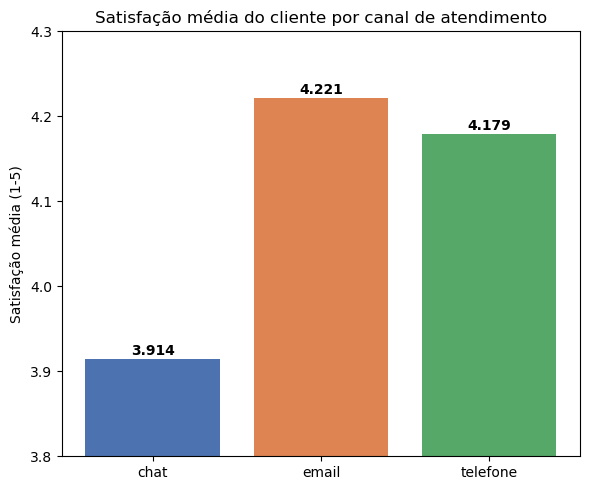

In [17]:
import matplotlib.pyplot as plt

canais_interesse = ["chat", "email", "telefone"]
df_plot = df[df["canal"].isin(canais_interesse)].dropna(subset=["satisfacao_cliente"])
medias = df_plot.groupby("canal")["satisfacao_cliente"].mean().reindex(canais_interesse)

plt.figure(figsize=(6, 5))
cores = ["#4C72B0", "#DD8452", "#55A868"]
plt.bar(medias.index, medias.values, color=cores)
plt.title("Satisfação média do cliente por canal de atendimento")
plt.ylabel("Satisfação média (1-5)")
plt.ylim(3.8, 4.3)  # PROBLEMA: eixo não começa em zero/no mínimo da escala
for i, v in enumerate(medias.values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Avaliação:**

| Critério | Avaliação |
|---|---|
| Tipo de gráfico | **Adequado**, gráfico de barras funciona pra comparar médias entre grupos. |
| Eixo Y começa em zero/no mínimo da escala? | **Não**, `plt.ylim(3.8, 4.3)` corta o eixo, mostrando só de 3.8 até 4.3, numa escala que vai de 1 a 5. |
| Exagera a diferença visualmente? | **Sim**, a barra do chat aparece quase vazia, mas a diferença real na escala de 1 a 5 é de só uns 7%. |
| Mostra a variabilidade/incerteza? | **Não**, só mostra a média, sem intervalo de confiança nem desvio padrão. |

### Tarefa 3. Corrija o gráfico onde a avaliação do item 2 identificou um problema, e escreva um título e uma legenda que comuniquem o achado de forma precisa ao time de suporte, sem exagerar a diferença real entre os canais.

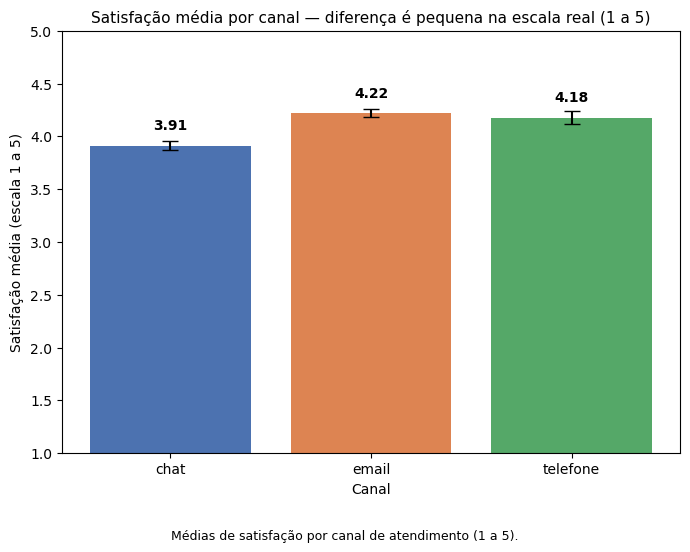

In [32]:
import numpy as np

ic_bootstrap = {
    "chat": (medias["chat"], 3.873, 3.953),
    "email": (medias["email"], 4.185, 4.256),
}

media_telefone = df_plot.loc[df_plot["canal"] == "telefone", "satisfacao_cliente"].mean()
std_telefone = df_plot.loc[df_plot["canal"] == "telefone", "satisfacao_cliente"].std()
n_telefone = df_plot.loc[df_plot["canal"] == "telefone", "satisfacao_cliente"].count()
erro_padrao_telefone = 1.96 * std_telefone / np.sqrt(n_telefone)

erros_inferior = [
    medias["chat"] - ic_bootstrap["chat"][1],
    medias["email"] - ic_bootstrap["email"][1],
    erro_padrao_telefone,
]
erros_superior = [
    ic_bootstrap["chat"][2] - medias["chat"],
    ic_bootstrap["email"][2] - medias["email"],
    erro_padrao_telefone,
]

legenda = "Médias de satisfação por canal de atendimento (1 a 5)."

plt.figure(figsize=(7, 5.5))
plt.bar(medias.index, medias.values, color=cores,
        yerr=[erros_inferior, erros_superior], capsize=6)
plt.title("Satisfação média por canal — diferença é pequena na escala real (1 a 5)", fontsize=11)
plt.ylabel("Satisfação média (escala 1 a 5)")
plt.xlabel("Canal")
plt.ylim(1, 5)
for i, v in enumerate(medias.values):
    plt.text(i, v + 0.15, f"{v:.2f}", ha="center", fontweight="bold")
plt.figtext(0.5, 0.01, legenda, wrap=True, ha="center", fontsize=9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Exercício 8

### Contexto

Para consolidar tudo o que foi trabalhado neste TP, seu líder técnico pediu um mini pipeline de análise assistida por IA, do início ao fim, sobre um recorte diferente do dataset: os tickets da categoria "bug" nos 30 dias mais recentes do período coberto pela base. O objetivo é demonstrar que você consegue conduzir o ciclo completo (limpeza com IA, formulação de perguntas, análise descritiva, comparação por intervalo de confiança e avaliação crítica) de forma independente, sem depender de um roteiro exercício a exercício.

### Tarefa
1. Use um LLM para gerar e revisar o código de limpeza do recorte de tickets de categoria "bug" nos 30 dias mais recentes do período coberto pela base.
2. Formule, com apoio de IA, uma pergunta analítica relevante sobre esse recorte que envolva comparar uma métrica numérica entre dois subgrupos, e obtenha a resposta com código gerado por LLM.
3. Peça ao LLM que estruture essa comparação; se ele sugerir um teste de hipótese clássico com p-valor, redirecione a análise para intervalos de confiança via scipy.stats.bootstrap, como praticado nos Exercícios 5 e 6, e peça ao LLM que explique o resultado. Valide essa explicação por escrito antes de aceitá-la.
4. Feche com uma avaliação crítica de todo o processo: aponte um ponto em que a IA foi confiável e um ponto em que sua revisão humana foi indispensável.


### Tarefa 1. Use um LLM para gerar e revisar o código de limpeza do recorte de tickets de categoria "bug" nos 30 dias mais recentes do período coberto pela base.

**Prompt utilizado:**

> Preciso de código pandas para gerar o recorte de tickets categoria=='bug' nos 30 dias mais recentes do período coberto pela base (não os últimos 30 dias a partir de hoje — a partir da data MÁXIMA presente no próprio dataset). Depois, aplique uma limpeza básica nesse recorte (trate nulos de satisfacao_cliente se fizer sentido, sem inventar dados).

**Resposta do LLM (próxima célula):**

In [19]:
import pandas as pd

data_max = df["data_abertura"].max()
data_inicio_janela = data_max - pd.Timedelta(days=29)

df_bug_recente = df[
    (df["categoria"] == "bug") &
    (df["data_abertura"] >= data_inicio_janela) &
    (df["data_abertura"] <= data_max)
].copy()

n_nulos_satisfacao = df_bug_recente["satisfacao_cliente"].isna().sum()
print(f"Nulos em satisfacao_cliente mantidos como NaN: {n_nulos_satisfacao} de {len(df_bug_recente)}")

print("Data máxima do dataset:", data_max.date())
print("Janela considerada:", data_inicio_janela.date(), "até", data_max.date())
print("Shape do recorte (bug, últimos 30 dias da base):", df_bug_recente.shape)

Nulos em satisfacao_cliente mantidos como NaN: 19 de 230
Data máxima do dataset: 2026-07-03
Janela considerada: 2026-06-04 até 2026-07-03
Shape do recorte (bug, últimos 30 dias da base): (230, 13)


### Tarefa 2. Formule, com apoio de IA, uma pergunta analítica relevante sobre esse recorte que envolva comparar uma métrica numérica entre dois subgrupos, e obtenha a resposta com código gerado por LLM.

**Prompt utilizado:**

> Com esse recorte, me ajude a formular UMA pergunta analítica relevante que envolva comparar uma métrica numérica entre dois subgrupos desse recorte.

**Resposta do LLM (candidatas):**
1. Tempo de resolução por canal (chat vs telefone) — **recomendada**
2. Satisfação por prioridade (alta/critica vs baixa/media)
3. Tempo de resposta por segmento

### Tarefa 3. Peça ao LLM que estruture essa comparação; se ele sugerir um teste de hipótese clássico com p-valor, redirecione a análise para intervalos de confiança via scipy.stats.bootstrap, como praticado nos Exercícios 5 e 6, e peça ao LLM que explique o resultado. Valide essa explicação por escrito antes de aceitá-la.

**Prompt utilizado (estruturar comparação):**

> Vou com a pergunta que você recomendou. Estruture a comparação estatística entre os dois subgrupos escolhidos.

**Resposta do LLM (sugestão inicial, com p-valor):** teste t de Welch (`scipy.stats.ttest_ind(..., equal_var=False)`), com Mann-Whitney U como alternativa não paramétrica — o LLM sugeriu p-valor por padrão de novo, mesmo já "tendo praticado" bootstrap no Exercício 5.

**Prompt de redirecionamento:**

> Como praticamos antes, prefiro intervalos de confiança via scipy.stats.bootstrap em vez de p-valor. Redireciona e me dá o código final, calculando o IC 95% de tempo_resolucao_horas para os dois subgrupos que você recomendou, separadamente. Depois, explique o resultado.

**Resposta do LLM:** código abaixo (executado sobre `df_bug_recente` real).

**Explicação do LLM sobre o resultado:** 

Cada IC bootstrap estima a faixa plausível da média populacional de tempo de resolução por canal; o grupo menor (telefone, n=58) tende a ter IC mais largo; não sobreposição dos ICs é evidência de diferença real, análoga (não idêntica) a uma diferença estatisticamente significativa; essa abordagem entrega uma faixa de incerteza em horas, mais interpretável operacionalmente do que um p-valor binário.

**Validação da explicação:**

Essa explicação tá certa. Ela descreve o IC do jeito correto, sem falar em probabilidade, faland certo que o grupo menor tende a ter IC mais largo, e não fala em causa dessa vez. Não achei os mesmos erros que vi nos outros exercícios.

In [33]:
import numpy as np
from scipy import stats

tempo_chat = df_bug_recente.loc[
    df_bug_recente["canal"] == "chat", "tempo_resolucao_horas"
].dropna().to_numpy()

tempo_telefone = df_bug_recente.loc[
    df_bug_recente["canal"] == "telefone", "tempo_resolucao_horas"
].dropna().to_numpy()

rng = np.random.default_rng(42)

res_chat = stats.bootstrap(
    (tempo_chat,), statistic=np.mean, n_resamples=10000,
    confidence_level=0.95, method="percentile", random_state=rng,
)
res_telefone = stats.bootstrap(
    (tempo_telefone,), statistic=np.mean, n_resamples=10000,
    confidence_level=0.95, method="percentile", random_state=rng,
)

print("Chat     - média:", round(tempo_chat.mean(), 3), "n =", len(tempo_chat))
print("Chat     - IC 95%:", res_chat.confidence_interval)

print("Telefone - média:", round(tempo_telefone.mean(), 3), "n =", len(tempo_telefone))
print("Telefone - IC 95%:", res_telefone.confidence_interval)

overlap = not (
    res_chat.confidence_interval.high < res_telefone.confidence_interval.low
    or res_telefone.confidence_interval.high < res_chat.confidence_interval.low
)
print("\nOs intervalos se sobrepõem?", overlap)

Chat     - média: 7.294 n = 72
Chat     - IC 95%: ConfidenceInterval(low=6.627057548436967, high=7.969986157006846)
Telefone - média: 10.614 n = 58
Telefone - IC 95%: ConfidenceInterval(low=9.396678818095547, high=11.99205625195323)

Os intervalos se sobrepõem? False


### Tarefa 4. Feche com uma avaliação crítica de todo o processo: aponte um ponto em que a IA foi confiável e um ponto em que sua revisão humana foi indispensável.

**Resposta:**

**A IA foi confiável pra gerar código**: a limpeza, os cálculos e o IC bootstrap funcionaram certo de primeira, em todos os exercícios, sem eu precisar corrigir nada.

**Onde a revisão humana foi indispensável**: 
- a IA sugeriu teste de hipótese com p-valor primeiro, só foi pra intervalo de confiança quando eu pedi.
- escolher qual pergunta seguir, e o que os números significam pro negócio, a IA não sabe o que é prioridade para o Negócio.